#Data Analyst with Python

**by Raden Wahyuni Qoyyumiah**

 with EDA

In [ ]:
# data wrangling library
import pandas as pd
import numpy as np

# data viz library
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# statistics library
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv(
    '/content/world_happiness_combined.csv',
    sep=';'
)
df.head()

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,"7,587","8,26132","0,9624",73,"0,99379","0,37289","0,23941",2015
1,2,Iceland,Western Europe,"7,561","7,70416",1,73,"0,93884","0,54819","0,74371",2015
2,3,Denmark,Western Europe,"7,527","7,84114","0,9703",70,"0,96962","0,42894","0,12382",2015
3,4,Norway,Western Europe,"7,522","8,631","0,94917",71,1,"0,43598","0,3386",2015
4,5,Canada,North America and ANZ,"7,427","7,84595","0,94322",71,"0,94511","0,5756","0,40285",2015


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Ranking                       1502 non-null   int64 
 1   Country                       1502 non-null   object
 2   Regional indicator            1502 non-null   object
 3   Happiness score               1502 non-null   object
 4   GDP per capita                1502 non-null   object
 5   Social support                1502 non-null   object
 6   Healthy life expectancy       1502 non-null   int64 
 7   Freedom to make life choices  1502 non-null   object
 8   Generosity                    1502 non-null   object
 9   Perceptions of corruption     1502 non-null   object
 10  Year                          1502 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 129.2+ KB


In [ ]:
df.describe()

,Ranking,Healthy life expectancy,Year
count,1502.000000,1502.000000,1502.000000
mean,76.035286,66.670439,2019.374834
std,43.865013,7.671376,2.856316
min,1.000000,39.000000,2015.000000
25%,38.000000,62.000000,2017.000000
50%,76.000000,68.000000,2019.000000
75%,114.000000,72.000000,2022.000000
max,158.000000,85.000000,2024.000000


In [ ]:
df.isna().sum()

,0
Ranking,0
Country,0
Regional indicator,0
Happiness score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Country'].unique()

array(['Switzerland', 'Iceland', 'Denmark', 'Norway', 'Canada', 'Finland',
       'Netherlands', 'Sweden', 'New Zealand', 'Australia', 'Israel',
       'Costa Rica', 'Austria', 'Mexico', 'United States', 'Brazil',
       'Luxembourg', 'Ireland', 'Belgium', 'United Arab Emirates',
       'United Kingdom', 'Oman', 'Venezuela', 'Singapore', 'Panama',
       'Germany', 'Chile', 'Qatar', 'France', 'Argentina',
       'Czech Republic', 'Uruguay', 'Colombia', 'Thailand',
       'Saudi Arabia', 'Spain', 'Malta', 'Taiwan', 'Kuwait', 'Suriname',
       'Trinidad and Tobago', 'El Salvador', 'Guatemala', 'Uzbekistan',
       'Slovakia', 'Japan', 'South Korea', 'Ecuador', 'Bahrain', 'Italy',
       'Bolivia', 'Moldova', 'Paraguay', 'Kazakhstan', 'Slovenia',
       'Lithuania', 'Nicaragua', 'Peru', 'Belarus', 'Poland', 'Malaysia',
       'Croatia', 'Libya', 'Russia', 'Jamaica', 'North Cyprus', 'Cyprus',
       'Algeria', 'Kosovo', 'Turkmenistan', 'Mauritius', 'Hong Kong',
       'Estonia', 'Indonesi

In [ ]:
df['Country'].nunique()

175

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='ignore')

In [ ]:
df['GDP per capita'] = df['GDP per capita'].str.replace(',', '.').astype(float)
df.info()

AttributeError: Can only use .str accessor with string values!

<Axes: ylabel='Frequency'>

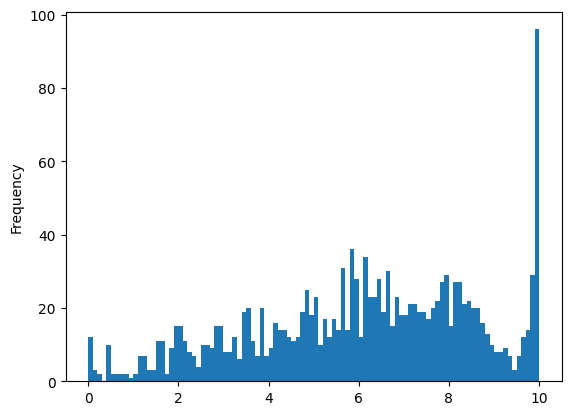

In [ ]:
df['GDP per capita'].plot(kind='hist', bins=100)

In [ ]:
negara_count = df['Country'].value_counts().head(5)

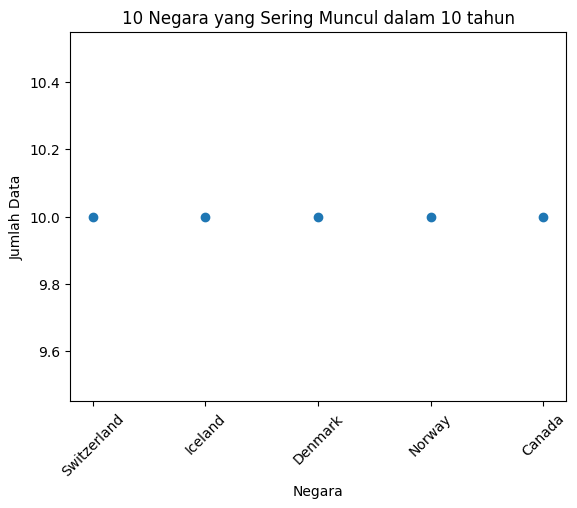

In [ ]:
# Plot
plt.scatter(negara_count.index, negara_count.values)
plt.title('10 Negara yang Sering Muncul dalam 10 tahun')
plt.xlabel('Negara')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45)
plt.show()

In [ ]:
jumlah_negara = df['Country'].nunique()

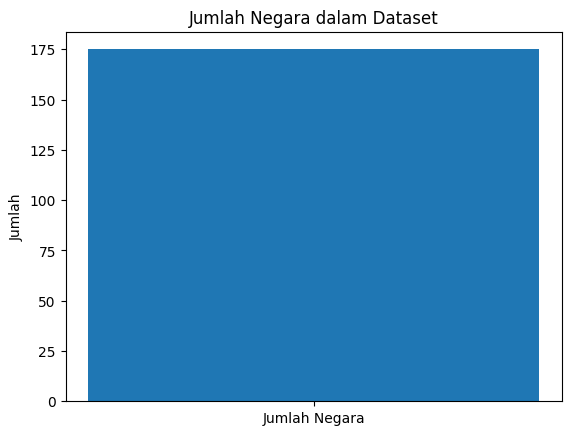

In [ ]:
# Buat grafik
plt.bar(['Jumlah Negara'], [jumlah_negara])
plt.title('Jumlah Negara dalam Dataset')
plt.ylabel('Jumlah')
plt.show()

In [ ]:
df['Social support'] = df['Social support'].str.replace(',', '.').astype(float)
df['Freedom to make life choices'] = df['Freedom to make life choices'].str.replace(',', '.').astype(float)
df['Generosity'] = df['Generosity'].str.replace(',', '.').astype(float)
df['Perceptions of corruption'] = df['Perceptions of corruption'].str.replace(',', '.').astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ranking                       1502 non-null   int64  
 1   Country                       1502 non-null   object 
 2   Regional indicator            1502 non-null   object 
 3   Happiness score               1502 non-null   object 
 4   GDP per capita                1502 non-null   float64
 5   Social support                1502 non-null   float64
 6   Healthy life expectancy       1502 non-null   int64  
 7   Freedom to make life choices  1502 non-null   float64
 8   Generosity                    1502 non-null   float64
 9   Perceptions of corruption     1502 non-null   float64
 10  Year                          1502 non-null   int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 129.2+ KB


In [ ]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ranking                       1502 non-null   int64         
 1   Country                       1502 non-null   object        
 2   Regional indicator            1502 non-null   object        
 3   Happiness score               1502 non-null   object        
 4   GDP per capita                1502 non-null   float64       
 5   Social support                1502 non-null   float64       
 6   Healthy life expectancy       1502 non-null   int64         
 7   Freedom to make life choices  1502 non-null   float64       
 8   Generosity                    1502 non-null   float64       
 9   Perceptions of corruption     1502 non-null   float64       
 10  Year                          1502 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
features = df[['Happiness score', 'GDP per capita',
               'Social support', 'Healthy life expectancy']]


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

ValueError: could not convert string to float: '7,587'

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

NameError: name 'scaled_features' is not defined

In [ ]:
print(df[['Country', 'Year', 'Cluster']].head())

       Country       Year  Cluster
0  Switzerland 2015-01-01        1
1      Iceland 2015-01-01        1
2      Denmark 2015-01-01        1
3       Norway 2015-01-01        1
4       Canada 2015-01-01        1


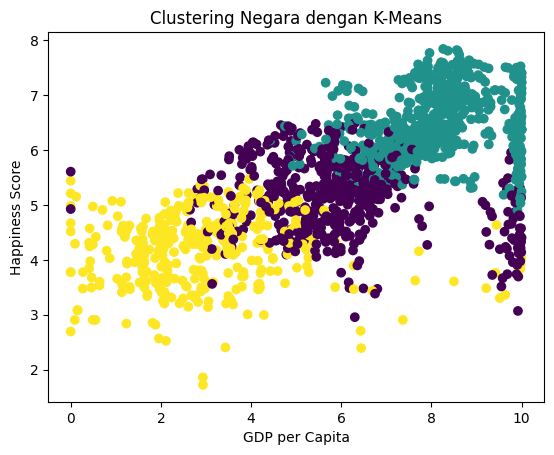

In [ ]:
plt.scatter(
    df['GDP per capita'],
    df['Happiness score'],
    c=df['Cluster']
)
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.title('Clustering Negara dengan K-Means')
plt.show()


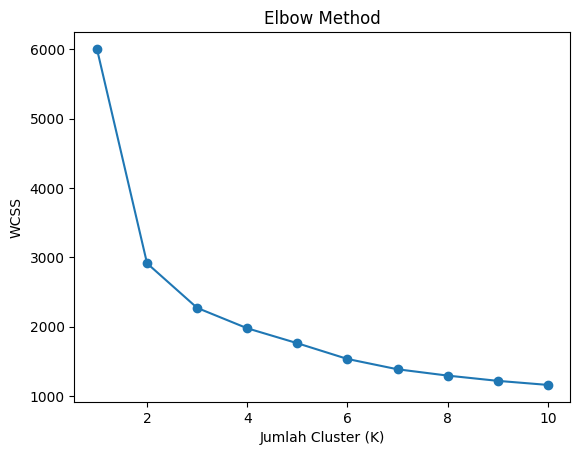

In [ ]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()
